# Support Vector Machine Classification

- A Support Vector Machine (SVM) is a supervised machine learning algorithm used mainly for classification (and sometimes regression).
- I implemented Support Vector Machine classification using the Breast Cancer Wisconsin dataset because it’s small, clean, and has binary classes with both linear and nonlinear patterns, making it ideal for SVM.

### 1. Import libraries

In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.decomposition import PCA

### 2. Load dataset

In [2]:
# Load dataset
data = load_breast_cancer(as_frame=True) # Load dataset as a pandas DataFrame instead of NumPy arrays

df = data.frame.copy() # Here, df is a copy of the full DataFrame, where data.frame returns the full DataFrame (features + target)
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


### 3. Explore the dataset (EDA)

#### 3.1 Basic information

In [3]:
# Understand the dataset structure 
print('Summary of DataFrame’s structure:\n')
df.info()

# Check Summary statistics
print('\nSummary statistics:\n', df.describe())

Summary of DataFrame’s structure:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    floa

#### 3.2 Correlation heatmap

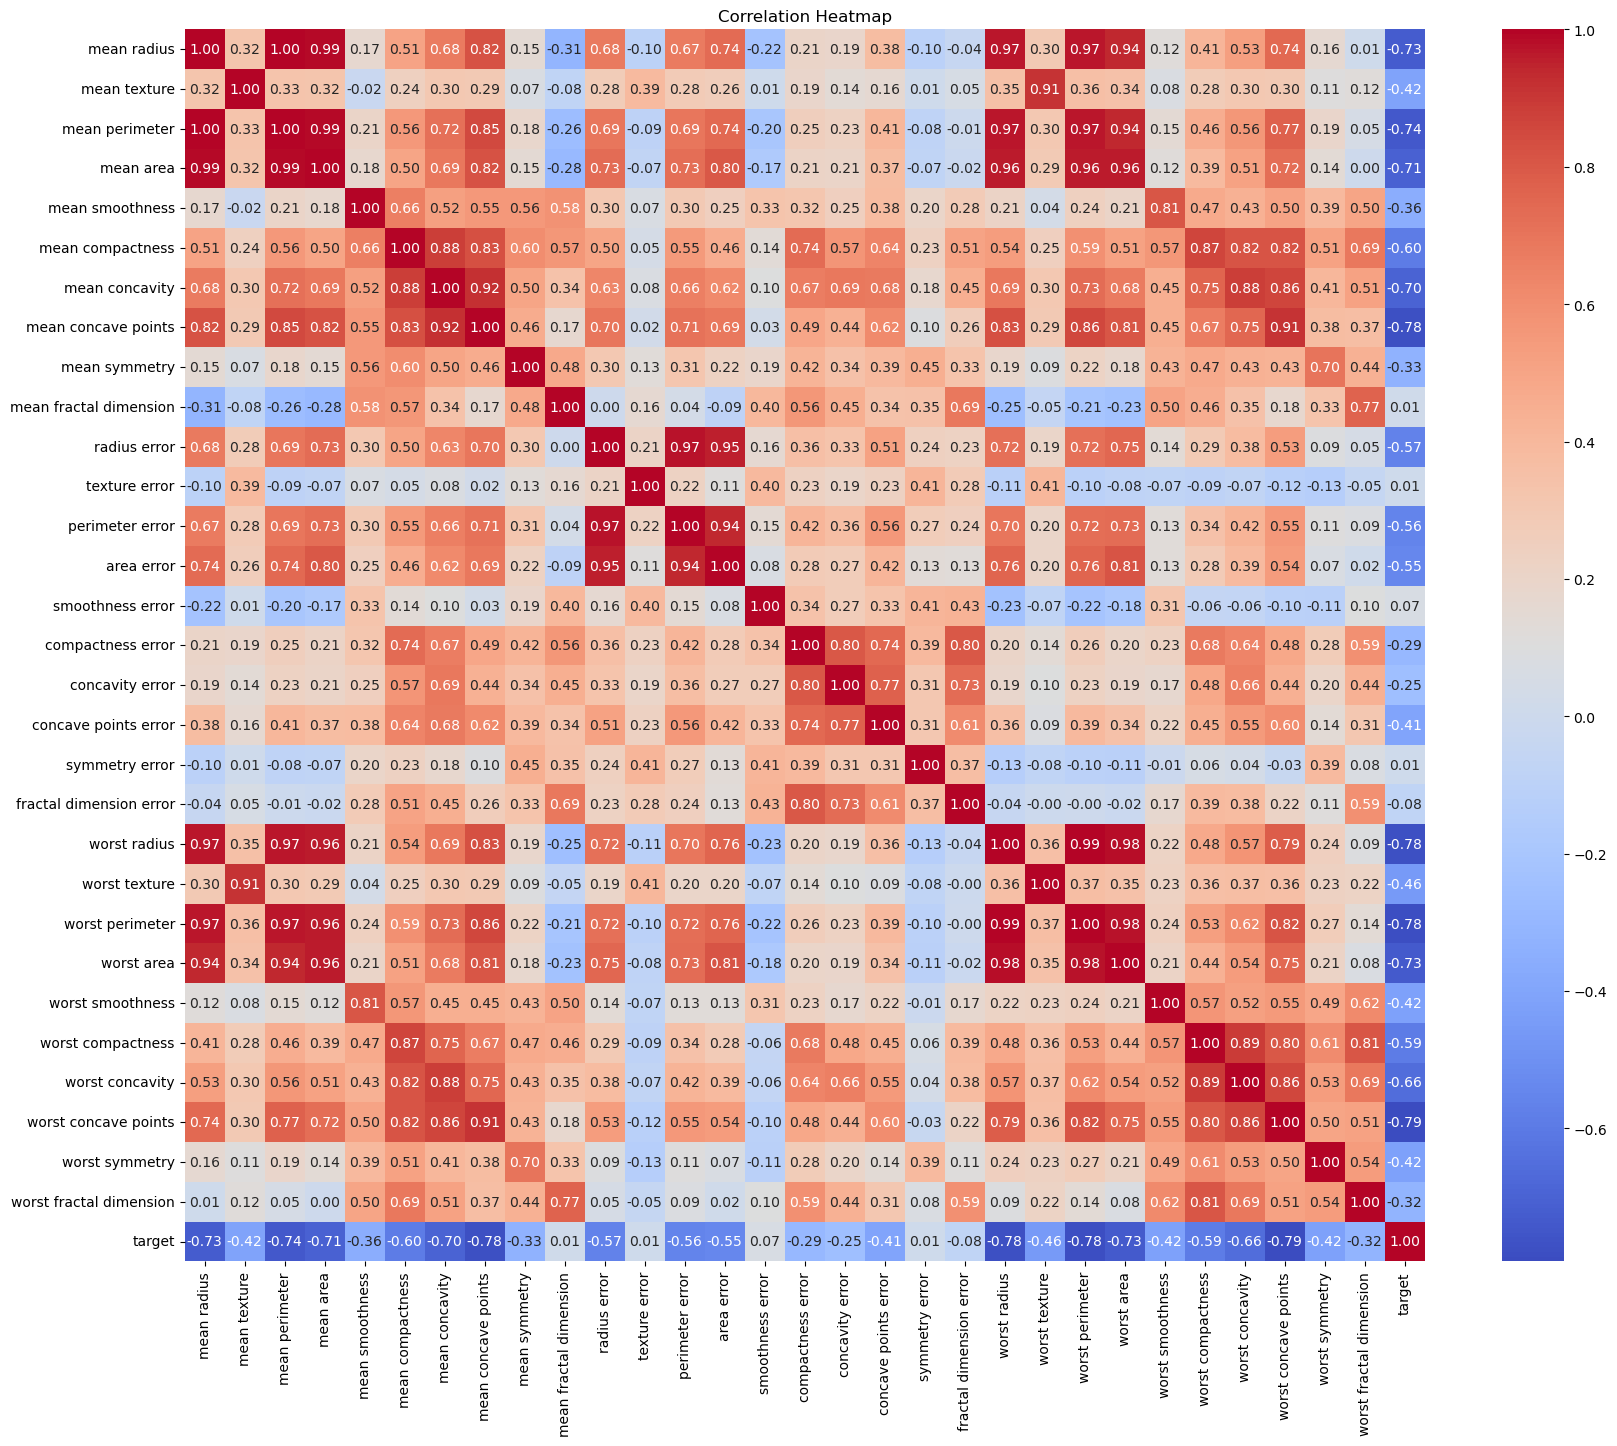

In [4]:
# Visualize correlations (Pearson correlation/linear correlation) between features and target
plt.figure(figsize=(20, 16))
sns.heatmap(data=df.corr(), cmap='coolwarm', annot=True, fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

#### 3.3 Class distribution

Class counts: target
1    357
0    212
Name: count, dtype: int64


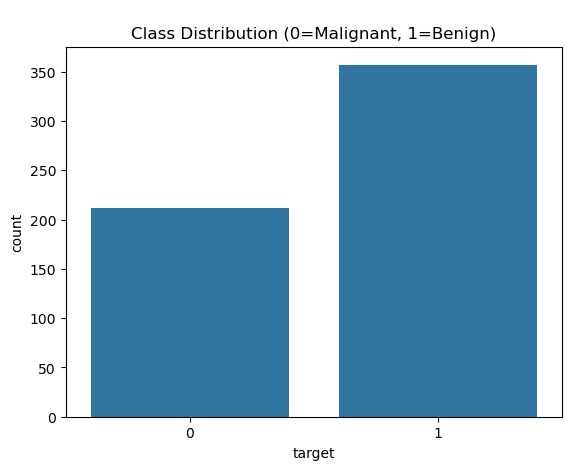

In [5]:
# Check class (target) distribution
class_counts = df['target'].value_counts()
print('Class counts:', class_counts)

# Visualise class distribution
sns.countplot(x=df['target'])
plt.title('\nClass Distribution (0=Malignant, 1=Benign)')
plt.show()

#### 3.4 Reduced pairplot (selected features for readability)

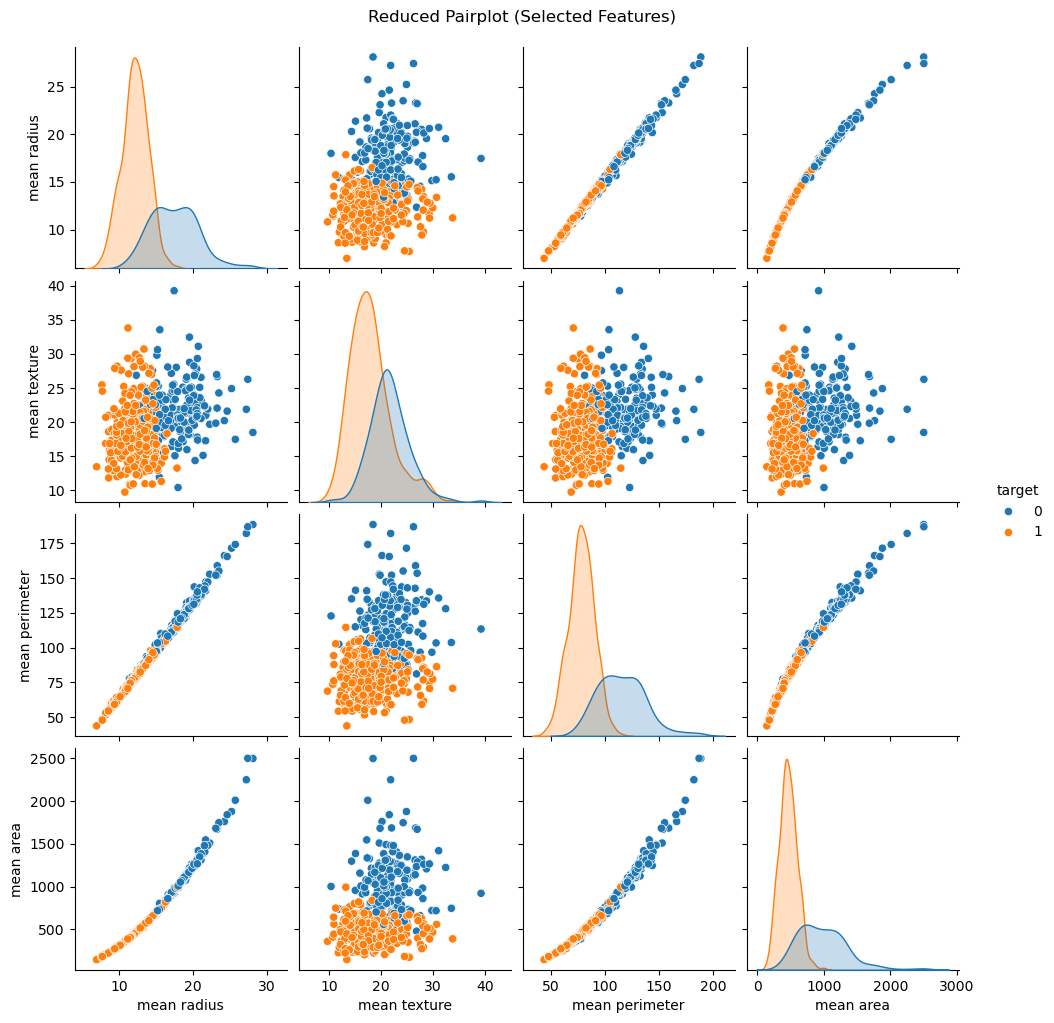

In [6]:
# Create a subset DataFrame with selected features
subset = df[['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'target']]

# Check pairwise relationships
g = sns.pairplot(data=subset, hue='target')
g.fig.suptitle('Reduced Pairplot (Selected Features)', y=1.02)
plt.show()

### 4. Define features and target

In [7]:
# Separate features and target
X = df.drop(columns='target')
y = df['target']

# Alternative ways to load full DataFrame, features only, and target only
# df = data.frame → full DataFrame (features + target)
# X = data.data → features only (DataFrame)
# y = data.target → target only (Series)

### 5. Split data into training and test sets (with stratification)

In [8]:
# Split data into training and test sets with stratification to preserve class ratio
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

### 6. Scale features

In [9]:
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### 7. Train baseline SVM model

In [10]:
# Initialize and train default SVM model (baseline model)
svm = SVC(kernel='rbf') 
# Here, the default 'rbf' (Radial Basis Function) kernel allows SVM to learn non‑linear relationship by transforming the input data into a higher‑dimensional feature space.

svm.fit(X_train_scaled, y_train)

SVC()

### 8. Make predictions using baseline model

In [11]:
# Predict on test data using baseline model
y_pred_baseline = svm.predict(X_test_scaled)

### 9. Evaluate baseline model performance

Baseline Accuracy: 0.9824561403508771

Classification report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



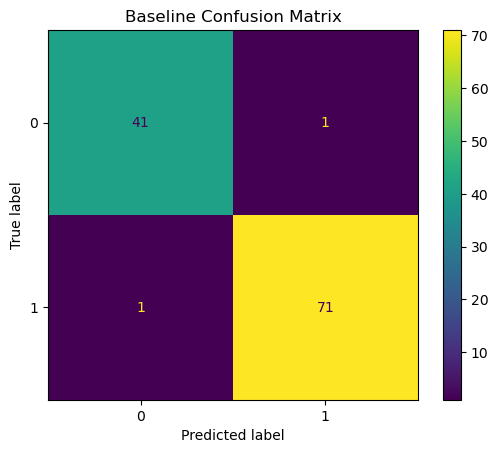

In [12]:
# Evaluate baseline performance
print("Baseline Accuracy:", accuracy_score(y_test, y_pred_baseline))
print('\nClassification report:\n', classification_report(y_test, y_pred_baseline))

# Confusion matrix visualization
cm = confusion_matrix(y_test, y_pred_baseline)
ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.title("Baseline Confusion Matrix")
plt.show()

### 10. Hyperparameter tuning to find the best parameters

#### 10.1 Define parameter grid

In [13]:
# Define parameter grid for tuning
param_grid = {
    'C': [0.1, 1, 10], # Regularization strength           
    'gamma': ['scale', 0.01, 0.001], # Kernel coefficient
    'kernel': ['rbf', 'linear'] # Kernel types
}

#### 10.2 Apply grid search with cross-validation

In [14]:
# Initialize and fit GridSearchCV 
grid = GridSearchCV(estimator=SVC(), param_grid=param_grid, cv=5, scoring='accuracy')
grid.fit(X_train_scaled, y_train)

GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [0.1, 1, 10], 'gamma': ['scale', 0.01, 0.001],
                         'kernel': ['rbf', 'linear']},
             scoring='accuracy')

#### 10.3 Find best parameters 

In [15]:
# Find best parameters
print("Best Parameters:", grid.best_params_)

Best Parameters: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}


### 11. Use the best model/Train the tuned model

In [16]:
# Retrieve best model
best_svm = grid.best_estimator_

### 12. Make predictions with the best model

In [17]:
# Make predictions using the tuned model
y_pred = best_svm.predict(X_test_scaled)
print('Tuned prediction:', y_pred)

Tuned prediction: [0 1 0 1 0 1 1 0 0 0 1 0 1 0 0 1 0 1 1 1 0 0 1 1 1 1 0 1 1 1 1 1 1 1 0 0 1
 1 1 0 1 1 1 0 0 1 1 1 1 0 1 1 1 1 1 1 1 0 0 1 1 1 1 1 0 0 1 1 1 1 1 1 1 0
 0 0 0 1 1 1 1 1 0 1 0 1 1 1 1 1 1 1 0 0 0 1 0 1 0 1 0 0 0 1 0 0 1 0 1 0 1
 0 1 1]


### 13. Evaluate the best/tuned model

Tuned Accuracy: 0.9824561403508771

Tuned Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



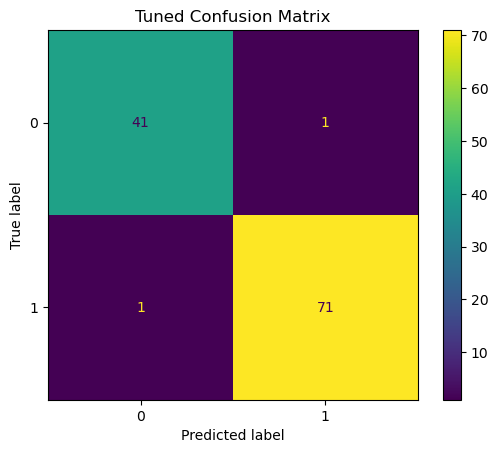

In [18]:
# Evaluate tuned model
print("Tuned Accuracy:", accuracy_score(y_test, y_pred))
print('\nTuned Classification Report:\n', classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.title("Tuned Confusion Matrix")
plt.show()

### 14. Visualize decision boundary in 2D using PCA

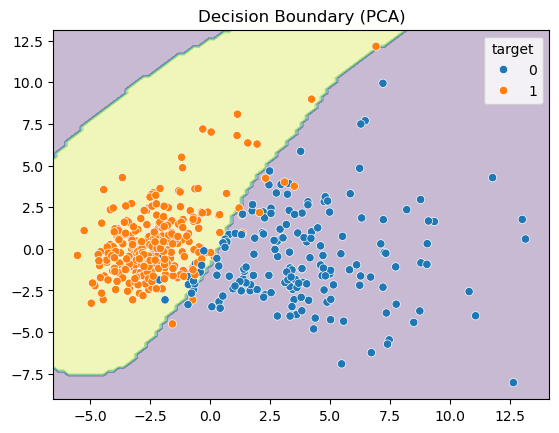

In [19]:
# Reduce high-dimensional data to 2D using PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_scaled)

# Train SVM on PCA-reduced data
svm_vis = SVC()
svm_vis.fit(X_pca, y_train)

# Create meshgrid for plotting decision boundary
x_min, x_max = X_pca[:, 0].min()-1, X_pca[:, 0].max()+1
y_min, y_max = X_pca[:, 1].min()-1, X_pca[:, 1].max()+1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                     np.linspace(y_min, y_max, 100))

# Predict class label over grid
Z = svm_vis.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot decision boundary
plt.contourf(xx, yy, Z, alpha=0.3)
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y_train)
plt.title("Decision Boundary (PCA)")
plt.show()

### 15. Predict for a new sample

In [20]:
# Select a sample from the dataset (for consistency)
new_sample = X.iloc[[0]]

# Scale sample
new_sample_scaled = scaler.transform(new_sample)

# Predict class
prediction = best_svm.predict(new_sample_scaled)
print("Predicted class:", prediction[0])

Predicted class: 0
